
# Exploratory Data Analysis and Sales Prediction using Python

**Course:** 602 – Data Analytics using Python  

This notebook is prepared strictly as per the university-prescribed project format.
It follows a clear academic sequence with markdown explanations between code cells.



## Step 1: Data Gathering and Understanding
The dataset is loaded using Pandas. Initial inspection helps understand structure, size, and data types.


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (same path style as original notebook)
df = pd.read_csv('SampleSuperstore.csv', encoding="latin1")
df.head()


AttributeError: module 'matplotlib' has no attribute '__version_info__'


### Dataset Information
This step identifies column data types and missing values.


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity


## Step 2: Data Cleaning
Check for missing values in the dataset.


In [ ]:

df.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## Step 3: Outlier Detection
Boxplots are used to detect extreme values in numerical variables.


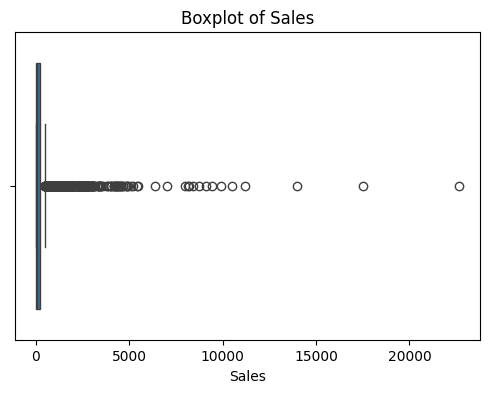

In [ ]:

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Sales'])
plt.title('Boxplot of Sales')
plt.show()



## Step 4: Data Distribution
Histogram helps understand the spread and skewness of sales data.


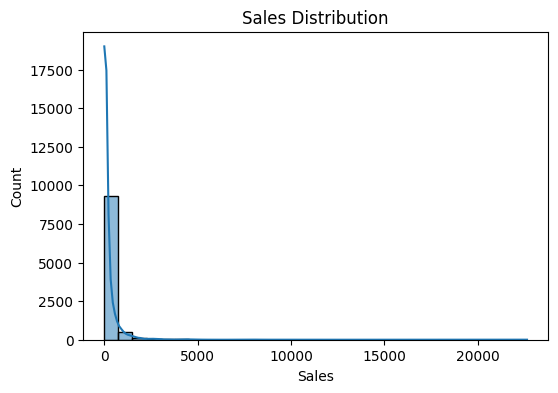

In [ ]:

plt.figure(figsize=(6,4))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Sales Distribution')
plt.show()



## Step 5: Data Normalization
Standardization is applied to numerical features.


In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Sales_scaled'] = scaler.fit_transform(df[['Sales']])
df[['Sales', 'Sales_scaled']].head()


,Sales,Sales_scaled
0,261.9600,0.051510
1,731.9400,0.805633
2,14.6200,-0.345368
3,957.5775,1.167688
4,22.3680,-0.332935



## Step 6: Exploratory Data Analysis (EDA)

### Univariate Analysis


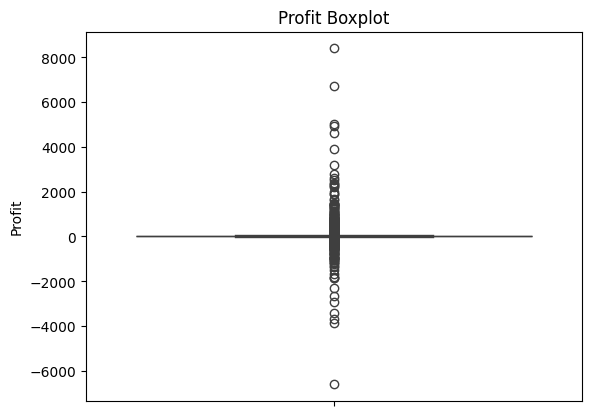

In [ ]:

sns.boxplot(y=df['Profit'])
plt.title('Profit Boxplot')
plt.show()



### Bivariate Analysis


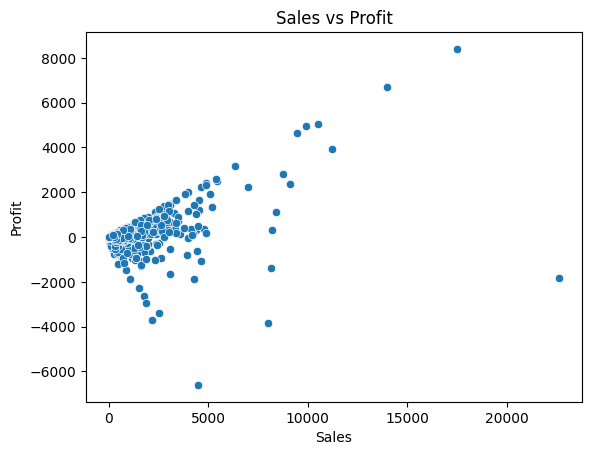

In [ ]:

sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs Profit')
plt.show()



### Multivariate Analysis
Correlation heatmap shows relationships among numerical variables.


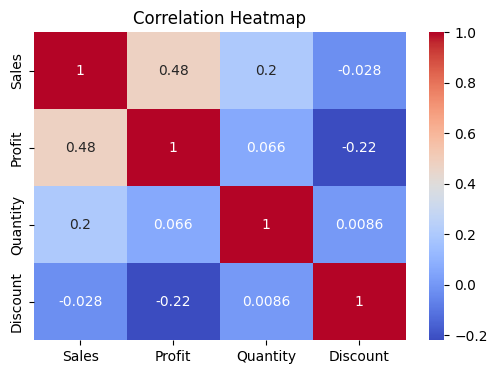

In [ ]:

plt.figure(figsize=(6,4))
sns.heatmap(df[['Sales','Profit','Quantity','Discount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



## Step 7: Linear Regression
Sales is predicted using Quantity and Discount.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Quantity','Discount']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


ModuleNotFoundError: No module named 'sklearn'


## Step 8: Model Evaluation
Model performance is evaluated using standard regression metrics.


In [ ]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, mae, r2


(569282.568307617, 274.98422630547105, 0.03625634814946299)

### Actual vs Predicted Sales

This plot compares actual sales values with predicted sales values.
If the model performs well, the points will lie close to the diagonal line.

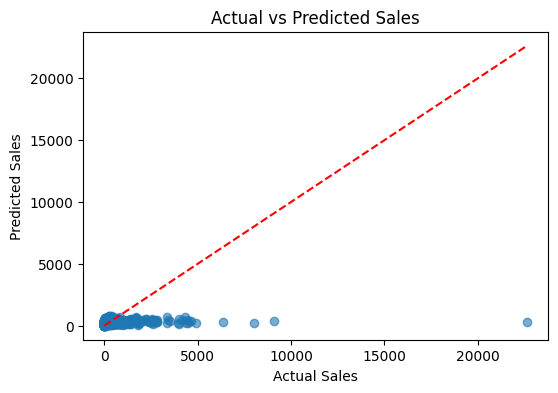

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


### Residual Plot

Residuals represent the difference between actual and predicted values.
A good model shows residuals randomly scattered around zero.

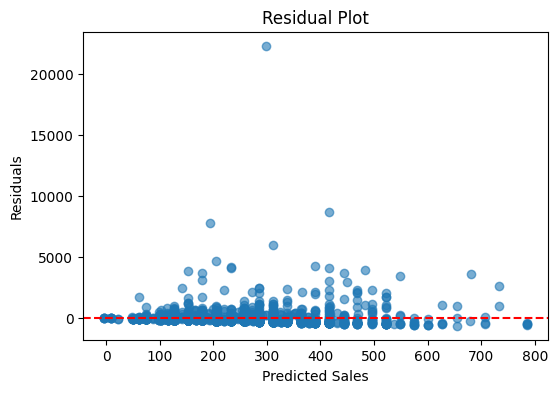

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


### Error Distribution

This plot shows the distribution of prediction errors.
A narrow and centered distribution indicates better model performance.

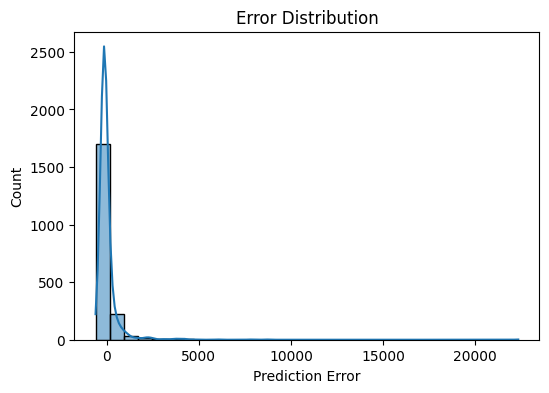

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)

plt.xlabel("Prediction Error")
plt.title("Error Distribution")
plt.show()



## Conclusion
The project demonstrates a complete data analytics workflow including EDA,
visualization, regression modeling, and evaluation.
